# 버거지수 단계 구분도


In [18]:
import json
import sys
import folium
import numpy as np
import pandas as pd
from pathlib import Path

# 프로젝트 루트를 path에 추가 (eda, features 모듈 import)
_root = Path().resolve()
if _root.name == "notebooks":
    _root = _root.parent.parent
sys.path.insert(0, str(_root))

from eda.lib.load_data import load_data
from eda.lib.config import SIDO_CODE_TO_NAME, INIT_POS, INIT_ZOOM

In [19]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# macOS 한글 폰트 (Supplemental 또는 시스템 폰트)
from pathlib import Path
_font_path = Path('/System/Library/Fonts/Supplemental/AppleGothic.ttf')
if not _font_path.exists():
    _font_path = Path('/System/Library/Fonts/AppleSDGothicNeo.ttc')
if _font_path.exists():
    _font = fm.FontProperties(fname=str(_font_path)).get_name()
    plt.rc('font', family=_font)

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

### 1. 데이터 로드


In [20]:
from eda.lib import load_data

df = load_data()

print('시군구 총계: ', len(df))
df.head()

시군구 총계:  229


,sido,sigungu,population,crime,violence,burgerking,lotteria,mcdonalds,kfc
0,서울,강남구,557345,17235,4012,9,7,9,8
1,서울,강동구,476942,5328,1697,4,8,3,3
2,서울,강북구,283597,4264,1320,3,5,4,2
3,서울,강서구,556171,7727,2337,7,12,4,4
4,서울,관악구,477812,8651,2520,6,9,1,3


In [21]:
# 세부 정보 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 229 entries, 0 to 228
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   sido        229 non-null    object
 1   sigungu     229 non-null    object
 2   population  229 non-null    int64 
 3   crime       229 non-null    int64 
 4   violence    229 non-null    int64 
 5   burgerking  229 non-null    int64 
 6   lotteria    229 non-null    int64 
 7   mcdonalds   229 non-null    int64 
 8   kfc         229 non-null    int64 
dtypes: int64(7), object(2)
memory usage: 16.2+ KB


In [22]:
df.describe()

,population,crime,violence,burgerking,lotteria,mcdonalds,kfc
count,2.290000e+02,229.000000,229.000000,229.000000,229.000000,229.000000,229.000000
mean,2.253620e+05,3383.489083,1061.301310,2.406114,5.698690,1.742358,1.048035
std,2.262235e+05,3515.000000,1058.359468,2.880082,5.833287,2.237832,1.625552
min,9.099000e+03,88.000000,29.000000,0.000000,0.000000,0.000000,0.000000
25%,4.869000e+04,654.000000,210.000000,0.000000,1.000000,0.000000,0.000000
50%,1.427890e+05,2237.000000,760.000000,1.000000,4.000000,1.000000,0.000000
75%,3.387850e+05,4858.000000,1551.000000,4.000000,8.000000,3.000000,1.000000
max,1.193005e+06,20374.000000,5781.000000,17.000000,31.000000,12.000000,8.000000


In [23]:
# 결측치 확인
df.isnull().sum()

sido          0
sigungu       0
population    0
crime         0
violence      0
burgerking    0
lotteria      0
mcdonalds     0
kfc           0
dtype: int64

In [24]:
# 버거 지수 계산
# 버거킹 + 맥도날드 + kfc 비율 / 롯데리아
burger_index = ((df['burgerking'] + df['mcdonalds'] + df['kfc'])/ df['lotteria']).round(1)

df['burger_index'] = burger_index
df.head(10)

,sido,sigungu,population,crime,violence,burgerking,lotteria,mcdonalds,kfc,burger_index
0,서울,강남구,557345,17235,4012,9,7,9,8,3.7
1,서울,강동구,476942,5328,1697,4,8,3,3,1.2
2,서울,강북구,283597,4264,1320,3,5,4,2,1.8
3,서울,강서구,556171,7727,2337,7,12,4,4,1.2
4,서울,관악구,477812,8651,2520,6,9,1,3,1.1
5,서울,광진구,331963,4744,1555,6,7,2,3,1.6
6,서울,구로구,388169,5928,1815,4,7,3,1,1.1
7,서울,금천구,225159,4815,1133,3,5,4,2,1.8
8,서울,노원구,491247,4636,1596,4,7,6,3,1.9
9,서울,도봉구,303228,3165,944,3,4,1,3,1.8


In [ ]:
# 버거지수 상위 5개
print(df.sort_values(by='burger_index', ascending=False).to_string())


    sido sigungu  population  crime  violence  burgerking  lotteria  mcdonalds  kfc  burger_index
0     서울     강남구      557345  17235      4012           9         7          9    8           3.7
14    서울     서초구      408376   8533      2196           6         7          6    8           2.9
23    서울      중구      120544   4475      1576           5         4          3    3           2.8
22    서울     종로구      138336   5101      1583           3         4          3    3           2.2
12    서울     마포구      361417   6587      2430           4         5          4    3           2.2
201   제주     제주시      488348  11560      3598           6         9          7    5           2.0
26    부산     금정구      209932   3143       935           4         4          3    1           2.0
18    서울     양천구      430976   4739      1483           5         5          3    2           2.0
8     서울     노원구      491247   4636      1596           4         7          6    3           1.9
10    서울    동대문구    

In [ ]:
# 버거지수 상위 5개 바 그래프
top5 = df.dropna(subset=['burger_index']).nlargest(5, 'burger_index')
labels = [f"{row['sido']} {row['sigungu']}" for _, row in top5.iterrows()]
values = top5['burger_index'].tolist()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values, color='#2ecc71', edgecolor='#27ae60', linewidth=1.2)
ax.set_xlabel('지역 (시도 시군구)', fontsize=11)
ax.set_ylabel('버거지수', fontsize=11)
ax.set_title('버거지수 상위 5개 지역', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(values) * 1.15)
plt.xticks(rotation=15, ha='right')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'{val}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

In [26]:
print(df.sort_values(by='burger_index', ascending=False).to_string())

    sido sigungu  population  crime  violence  burgerking  lotteria  mcdonalds  kfc  burger_index
0     서울     강남구      557345  17235      4012           9         7          9    8           3.7
14    서울     서초구      408376   8533      2196           6         7          6    8           2.9
23    서울      중구      120544   4475      1576           5         4          3    3           2.8
22    서울     종로구      138336   5101      1583           3         4          3    3           2.2
12    서울     마포구      361417   6587      2430           4         5          4    3           2.2
201   제주     제주시      488348  11560      3598           6         9          7    5           2.0
26    부산     금정구      209932   3143       935           4         4          3    1           2.0
18    서울     양천구      430976   4739      1483           5         5          3    2           2.0
8     서울     노원구      491247   4636      1596           4         7          6    3           1.9
10    서울    동대문구    

In [38]:
# ── IQR 이상치 탐지 ──
Q1 = valid['burger_index'].quantile(0.25)
Q3 = valid['burger_index'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

outliers = valid[(valid['burger_index'] > upper_bound) | (valid['burger_index'] < lower_bound)]

print("=" * 52)
print(" IQR 기반 이상치 탐지")
print("=" * 52)
print(f"  Q1 = {Q1:.3f}  |  Q3 = {Q3:.3f}  |  IQR = {IQR:.3f}")
print(f"  허용 범위 : [{lower_bound:.3f}, {upper_bound:.3f}]")
print(f"  이상치 지역 수 : {len(outliers)}")
print("-" * 52)
print(outliers[['region','district','burger_index','population','lotteria','global_sum']]
      .rename(columns={'region':'지역','district':'구','burger_index':'BI',
                       'population':'인구','lotteria':'롯데리아','global_sum':'글로벌합'})
      .to_string(index=False))


KeyError: 'burger_index'

### 2. 버거지수 시각화 준비


In [27]:
kor_map_path = Path('../../kor_map.json')
with open(kor_map_path, 'r', encoding='utf-8') as f:
  kor_map = json.load(f)
  
print('test\n')
print(kor_map['features'][0]['properties'])

test

{'SIG_CD': '11110', 'SIG_ENG_NM': 'Jongno-gu', 'SIG_KOR_NM': '종로구'}


In [28]:
import json
import folium
from folium.plugins import HeatMap

with open('../../kor_map.json', mode='rt', encoding='utf-8') as f:
    kor_map = json.load(f)
    f.close()

kor_map

{'type': 'FeatureCollection',
 'features': [{'type': 'Feature',
   'geometry': {'type': 'Polygon',
    'coordinates': [[[127.0117883275938, 37.58156996265317],
      [127.00800879591004, 37.58122954999857],
      [127.0079613875888, 37.581283323455494],
      [127.0068595920625, 37.582258416680304],
      [127.00675823851574, 37.582344861828666],
      [127.00706970427298, 37.58409106651521],
      [127.007010450639, 37.58429294416804],
      [127.00665515426985, 37.58542263406659],
      [127.00655088897183, 37.5855458573495],
      [127.00400221201136, 37.58780323133007],
      [127.00389163822067, 37.58774748964541],
      [127.00398806400376, 37.58794457819267],
      [127.00371685583974, 37.58804312430699],
      [127.00356578547876, 37.58809578059844],
      [127.00351730520883, 37.588145335615444],
      [127.00346300877048, 37.58832975918104],
      [127.00347220464906, 37.588415352620686],
      [127.00341542658575, 37.588531076079754],
      [127.003393485017, 37.588569079983

In [29]:
# 지역 코드 매핑
burger_index_by_region = {}
for _, row in df.iterrows():
  key = (row['sido'], row['sigungu'])
  burger_index_by_region[key] = row['burger_index']

In [30]:
# data.json과 동일한 시군구 정규화 사용 (매칭 실패 감소)
from features.utils.region import normalize_sigungu as region_normalize_sigungu

def normalize_sigungu_for_map(sig_kor, sido_name):
  """GeoJSON 시군구명 → data.json 키와 동일하게 정규화 (청원군→청주시 등 반영)"""
  if sig_kor == "세종특별자치시":
    return "세종시"
  return region_normalize_sigungu(sig_kor, sido=sido_name)

choropleth_data = []

for feature in kor_map['features']:
  sig_cd = feature['properties']['SIG_CD']
  sig_kor = feature['properties']['SIG_KOR_NM']
  
  # SIG_CD 첫 2자리 → 시도 (11=서울, 51=강원 등; 이 GeoJSON은 강원 51)
  sig_cd_str = str(sig_cd).strip()
  sido_code = sig_cd_str[:2] if len(sig_cd_str) >= 2 else ''
  sido_name = SIDO_CODE_TO_NAME.get(sido_code, '')
  
  # 시군구 정규화: data.json(count_all)과 동일 규칙 사용
  normalized_sigungu = normalize_sigungu_for_map(sig_kor, sido_name)
  
  # 정규화된 (sido, sigungu)로 매칭
  burger_index = burger_index_by_region.get((sido_name, normalized_sigungu))
  
  # 실패 시 원본 이름으로 재시도
  if burger_index is None:
    burger_index = burger_index_by_region.get((sido_name, sig_kor))

  choropleth_data.append({
    'SIG_CD': sig_cd, 
    'SIG_KOR_NM': sig_kor,
    'normalized_sigungu': normalized_sigungu,
    'sido': sido_name,
    'burger_index': burger_index if burger_index is not None else 0
  })  


In [31]:
df_map = pd.DataFrame(choropleth_data)
print(f'지도 데이터 지역 수: {len(df_map)}')
print(f'버거 지수가 0인 지역의 수: {len(df_map[df_map['burger_index'] == 0])}')

print(df_map.to_string())

지도 데이터 지역 수: 250
버거 지수가 0인 지역의 수: 69
    SIG_CD SIG_KOR_NM normalized_sigungu sido  burger_index
0    11110        종로구                종로구   서울           2.2
1    11140         중구                 중구   서울           2.8
2    11170        용산구                용산구   서울           1.5
3    11200        성동구                성동구   서울           0.6
4    11215        광진구                광진구   서울           1.6
5    11230       동대문구               동대문구   서울           1.8
6    11260        중랑구                중랑구   서울           0.9
7    11290        성북구                성북구   서울           1.1
8    11305        강북구                강북구   서울           1.8
9    11320        도봉구                도봉구   서울           1.8
10   11350        노원구                노원구   서울           1.9
11   11380        은평구                은평구   서울           1.0
12   11410       서대문구               서대문구   서울           1.4
13   11440        마포구                마포구   서울           2.2
14   11470        양천구                양천구   서울           2.0
15 

### 3. 단계 구분도 생성

- 버거지수에 따른 단계 구분도


In [32]:
# 버거지수를 카테고리 0, 1, 2, 3으로 구간화 (0 = 흰색)
df_map_for_viz = df_map.copy()
valid = df_map_for_viz['burger_index'].notna() & (df_map_for_viz['burger_index'] > 0)
df_map_for_viz['burger_cat'] = 0  # 기본 0 (버거지수 0 또는 결측 → 흰색)
if valid.any():
    # 양수 값만 33%, 66% 백분위로 1, 2, 3 구간 할당
    p33 = np.nanpercentile(df_map_for_viz.loc[valid, 'burger_index'], 33.33)
    p66 = np.nanpercentile(df_map_for_viz.loc[valid, 'burger_index'], 66.67)
    bi = df_map_for_viz['burger_index']
    df_map_for_viz.loc[valid & (bi <= p33), 'burger_cat'] = 1
    df_map_for_viz.loc[valid & (bi > p33) & (bi <= p66), 'burger_cat'] = 2
    df_map_for_viz.loc[valid & (bi > p66), 'burger_cat'] = 3

burger_cat_dict = df_map_for_viz.set_index('SIG_CD')['burger_cat'].to_dict()
burger_index_dict = df_map_for_viz.set_index('SIG_CD')['burger_index'].to_dict()
sigungu_name_dict = df_map.set_index('SIG_CD')['SIG_KOR_NM'].to_dict()
sido_name_dict = df_map.set_index('SIG_CD')['sido'].to_dict()

# GeoJSON에 카테고리·원래 버거지수 추가
for feature in kor_map['features']:
  sig_cd = feature['properties']['SIG_CD']
  feature['properties']['burger_cat'] = int(burger_cat_dict.get(sig_cd, 0))
  feature['properties']['burger_index'] = burger_index_dict.get(sig_cd)
  feature['properties']['sido_name'] = sido_name_dict.get(sig_cd, '')

In [ ]:
# 지도 생성 (카테고리 0=흰색, 1~3=연한색→진한색)
import branca.colormap as cm
step_cmap = cm.StepColormap(
    colors=['white', '#ffffb2', '#fecc5c', '#e31a1c'],
    index=[0, 1, 2, 3],
    vmin=0,
    vmax=3,
)

map = folium.Map(location=INIT_POS, zoom_start=INIT_ZOOM, tiles='CartoDB positron')

def style_fn(feature):
    props = feature.get('properties', {})
    sig_cd = props.get('SIG_CD') or props.get('sig_cd')
    sig_cd = str(sig_cd) if sig_cd is not None else None
    cat = burger_cat_dict.get(sig_cd, 0) if sig_cd else 0
    color = step_cmap(cat)
    return {'fillColor': color, 'color': 'black', 'weight': 1, 'fillOpacity': 0.7}

folium.GeoJson(kor_map, style_function=style_fn).add_to(map)
step_cmap.caption = '버거지수 (0=낮음, 3=높음)'
step_cmap.add_to(map)

# 시군구 표시용 레이어
label_layer = folium.FeatureGroup(name='지역명 표시', show=True)

In [34]:
from shapely.geometry import shape

# 각 지역 중심점에 시군구 이름 텍스트 표시
for feature in kor_map['features']:
  sig_cd = feature['properties']['SIG_CD']
  sig_kor = feature['properties']['SIG_KOR_NM']
  burger_idx = feature['properties'].get('burger_index', 0)
  
  # 지역 중심점 계산
  try:
    geom = shape(feature['geometry'])
    centroid = geom.centroid
    
    # 텍스트 라벨 추가
    folium.Marker(
      location=[centroid.y, centroid.x],
      icon=folium.DivIcon(html=f'''
        <div style="
          font-size: 9pt; 
          font-weight: bold;
          color: #333;
          text-align: center;
          white-space: nowrap;
          text-shadow: 
            -1px -1px 0 #fff,  
             1px -1px 0 #fff,
            -1px  1px 0 #fff,
             1px  1px 0 #fff;
        ">
          {sig_kor}
        </div>
      ''')
    ).add_to(label_layer)
    
  except Exception as e:
    print(f"Warning: Could not add label for {sig_kor}: {e}")

# 라벨 레이어 표시
label_layer.add_to(map)
folium.LayerControl(collapsed=False).add_to(map)

map

### 인구 당 버거지수


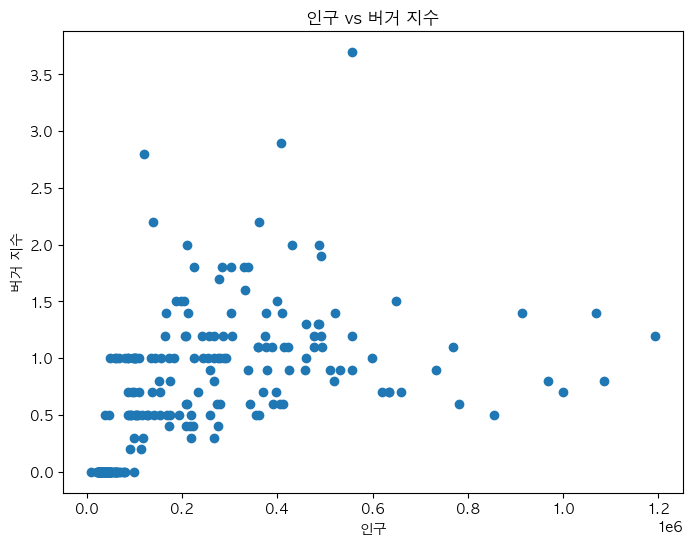

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df["population"], df["burger_index"])
plt.xlabel('인구')
plt.ylabel('버거 지수')
plt.title('인구 vs 버거 지수')
plt.show()

In [ ]:
# 상관계수 
df[["population", "burger_index"]].corr()

,population,burger_index
population,1.000000,0.511152
burger_index,0.511152,1.000000
